# 🛍️ Sephora — Segmentation Client
## Notebook 02 — Clustering Pipeline

Ce notebook implémente le pipeline complet de segmentation client :
1. Audit des features → 2. Sélection → 3. Preprocessing → 4. Cercle des corrélations →
5. K-Scan → 6. Modèle final → 7. Profiling des segments → 8. Export

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from src.config import (
    DATA_PROCESSED_PATH, RANDOM_STATE, K_RANGE,
    FEATURES_DROP, FEATURES_CONTINUOUS, FEATURES_ONEHOT,
    FEATURE_CATEGORIES, CATEGORY_COLORS,
)
from src.preprocessing import preprocess_for_clustering
from src.clustering import (
    evaluate_kmeans_k_range, get_top_k_candidates,
    run_kmeans_final, run_hierarchical, log_clustering_run,
)
from src.visualization import plot_correlation_circle, plot_elbow_curves

os.makedirs("figures", exist_ok=True)

# --- MLflow experiment setup (R1.5) ---
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("sephora-customer-segmentation")
print("MLflow URI:", mlflow.get_tracking_uri())

/Users/milanviallet/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow URI: sqlite:///mlflow.db


In [2]:
df_customers = pd.read_csv(DATA_PROCESSED_PATH + "customers_features.csv")
print(f"Loaded customers_features.csv — {df_customers.shape[0]:,} clients × {df_customers.shape[1]} colonnes")

Loaded customers_features.csv — 64,469 clients × 54 colonnes


---
# Section 2 — Audit des features

Chaque feature conservée est classée dans l'une des 6 catégories marketing définies dans `src/config.py → FEATURE_CATEGORIES`.
Ce référentiel guide l'interprétation métier des clusters.

| Catégorie | Description | Exemples |
|---|---|---|
| **profil** | Qui est le client — traits socio-démographiques | `age`, `gender`, `country`, `loyalty_numeric` |
| **valeur** | Combien vaut le client — indicateurs RFM | `recency_days`, `frequency`, `monetary_total` |
| **affinite_produit** | Ce que le client achète — ratios produit/marché | `axe_skincare_ratio`, `dominant_axe` |
| **comportement** | Comment le client achète — panier, marques | `avg_units_per_basket`, `nb_unique_brands` |
| **canal** | Où le client achète — distribution omnicanale | `store_ratio`, `dominant_channel` |
| **dates** | Ancienneté fidélité | `subscription_tenure_days` |

In [3]:
from src.config import FEATURE_CATEGORIES

print("=== FEATURE_CATEGORIES ===\n")
for cat, feats in FEATURE_CATEGORIES.items():
    print(f"  {cat:20s} ({len(feats):2d} features) : {feats}")
print(f"\nTotal features référencées : {sum(len(v) for v in FEATURE_CATEGORIES.values())}")

=== FEATURE_CATEGORIES ===

  profil               ( 4 features) : ['age', 'gender', 'country', 'loyalty_numeric']
  valeur               ( 6 features) : ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'avg_basket_size_eur', 'discount_rate']
  affinite_produit     ( 9 features) : ['axe_make_up_ratio', 'axe_skincare_ratio', 'axe_fragrance_ratio', 'axe_haircare_ratio', 'axe_others_ratio', 'market_selective_ratio', 'market_exclusive_ratio', 'market_sephora_ratio', 'axis_diversity']
  comportement         ( 3 features) : ['avg_units_per_basket', 'nb_unique_brands', 'nb_unique_stores']
  canal                ( 3 features) : ['store_ratio', 'click_collect_ratio', 'dominant_channel']
  dates                ( 1 features) : ['subscription_tenure_days']

Total features référencées : 26


---
# Section 3 — Sélection des features

Avant le preprocessing, les features suivantes ont été retirées du pipeline car elles ne constituent
pas des leviers marketing actionnables (`src/config.py → FEATURES_DROP`).

| Variable supprimée | Catégorie | Raison |
|---|---|---|
| `is_new_customer` | Zero variance | Constant = 1 pour toutes les lignes |
| `total_sales_eur` / `total_transactions` / `avg_sales_eur` | Doublons exacts | Dupliquent `monetary_total`, `frequency`, `monetary_avg` |
| `salesVatEUR_first_purchase` / `first_purchase_channel` | Doublons exacts | Dupliquent `first_purchase_amount`, `channel_recruitment` |
| `monetary_total_capped` / `frequency_capped` | Doublons winsorisés | Doublons de `monetary_total`, `frequency` |
| `loyalty_status` | Redondant | Version string de `loyalty_numeric` |
| `Axe_Desc_first_purchase` | Brut | Version non nettoyée de `first_purchase_axe` |
| `last_purchase_date` / `first_purchase_date` / `subscription_date` | Dates brutes | `recency_days` et `subscription_tenure_days` conservés |
| `is_outlier` | Flag opérationnel | Pas une feature comportementale |
| `total_quantity` / `total_lines` | Volume pur | `avg_units_per_basket` suffit et est normalisé |
| `customer_city` | Trop granulaire | ~12K modalités, inutilisable en clustering |
| `first_purchase_amount` / `channel_recruitment` / `first_purchase_axe` | Passé lointain | Ne reflètent plus le comportement actuel |
| `age_category` / `age_generation` | Redondant | Redondants avec `age` (continu, plus riche) |
| `total_discount_eur` / `cc_transactions` | Redondant | `discount_rate` et `click_collect_ratio` existent déjà |
| `dominant_axe` | Redondant | `argmax(axe_*_ratio)` — information redondante avec les 5 ratios continus |
| `dominant_market` | Redondant | `argmax(market_*_ratio)` — information redondante avec les 4 ratios continus |

**Résultat attendu :** 25 features continues + 9 dummies One-Hot (gender, dominant_channel, country) + 2 indicateurs de manquants = **36 features**.

In [4]:
from src.config import FEATURES_DROP, FEATURES_CONTINUOUS, FEATURES_ONEHOT

print(f"FEATURES_DROP ({len(FEATURES_DROP)} features) :")
for f in FEATURES_DROP:
    print(f"  - {f}")

# Vérifier qu'aucune feature supprimée n'apparaît dans les listes actives
suppressed_in_active = [f for f in FEATURES_DROP if f in FEATURES_CONTINUOUS + FEATURES_ONEHOT]
assert len(suppressed_in_active) == 0, f"Features supprimées encore actives : {suppressed_in_active}"
print(f"\n✓ Aucune feature supprimée dans FEATURES_CONTINUOUS ({len(FEATURES_CONTINUOUS)}) + FEATURES_ONEHOT ({len(FEATURES_ONEHOT)})")

FEATURES_DROP (28 features) :
  - is_new_customer
  - total_sales_eur
  - total_transactions
  - avg_sales_eur
  - salesVatEUR_first_purchase
  - first_purchase_channel
  - monetary_total_capped
  - frequency_capped
  - loyalty_status
  - Axe_Desc_first_purchase
  - last_purchase_date
  - first_purchase_date
  - subscription_date
  - is_outlier
  - dominant_axe
  - dominant_market
  - total_quantity
  - total_lines
  - customer_city
  - first_purchase_amount
  - channel_recruitment
  - first_purchase_axe
  - age_category
  - age_generation
  - total_discount_eur
  - cc_transactions
  - estore_ratio
  - market_others_ratio

✓ Aucune feature supprimée dans FEATURES_CONTINUOUS (23) + FEATURES_ONEHOT (3)


---
# Section 4 — Preprocessing

Le pipeline `preprocess_for_clustering()` enchaîne 3 étapes :

1. **Imputation** — médiane pour les numériques, `'Unknown'` pour les catégorielles, indicateurs de manquants (`has_age_info`, `has_first_purchase_info`)
2. **Encodage One-Hot** — 5 variables catégorielles → 18 dummies (`gender`, `dominant_channel`, `dominant_axe`, `dominant_market`, `country`)
3. **Scaling** — `StandardScaler` sur toutes les features (mean≈0, std≈1) pour que les distances euclidiennes soient homogènes

In [3]:
X_scaled, transformers = preprocess_for_clustering(df_customers, return_transformers=True)

=== Missing Rate per Feature ===
  age: 8617 missing (13.37%)
  age_category: 19638 missing (30.46%)
  age_generation: 20937 missing (32.48%)
  customer_city: 3371 missing (5.23%)
  subscription_date: 503 missing (0.78%)
  channel_recruitment: 40418 missing (62.69%)
  salesVatEUR_first_purchase: 40418 missing (62.69%)
  Axe_Desc_first_purchase: 40418 missing (62.69%)
  subscription_tenure_days: 503 missing (0.78%)
  first_purchase_axe: 40418 missing (62.69%)
  first_purchase_channel: 40418 missing (62.69%)
  first_purchase_amount: 40418 missing (62.69%)
Dropped 29 useless features: ['is_new_customer', 'total_sales_eur', 'total_transactions', 'avg_sales_eur', 'salesVatEUR_first_purchase', 'first_purchase_channel', 'monetary_total_capped', 'frequency_capped', 'loyalty_status', 'Axe_Desc_first_purchase', 'last_purchase_date', 'first_purchase_date', 'subscription_date', 'is_outlier', 'dominant_axe', 'dominant_market', 'total_quantity', 'total_lines', 'customer_city', 'first_purchase_amount

In [4]:
assert X_scaled.shape[1] == 33, f"Expected 33 features, got {X_scaled.shape[1]}"
assert X_scaled.isnull().sum().sum() == 0, "NaN values found"
assert not np.isinf(X_scaled.values).any(), "Inf values found"
print(f"X_scaled shape : {X_scaled.shape}")
print(f"Mean range     : [{X_scaled.mean().min():.6f}, {X_scaled.mean().max():.6f}] ≈ 0 ✓")
print(f"Std range      : [{X_scaled.std(ddof=0).min():.6f}, {X_scaled.std(ddof=0).max():.6f}] ≈ 1 ✓")
print("✓ Preprocessing validé : 33 features, zero NaN, zero Inf, mean≈0, std≈1")

X_scaled shape : (64469, 33)
Mean range     : [-0.000000, 0.000000] ≈ 0 ✓
Std range      : [1.000000, 1.000000] ≈ 1 ✓
✓ Preprocessing validé : 33 features, zero NaN, zero Inf, mean≈0, std≈1


---
# Section 5 — Cercle des corrélations

Inspectez le graphique ci-dessous. Les paires de flèches pointant dans la même direction (angle < 26°) peuvent indiquer des features redondantes. C'est à vous de décider lesquelles retirer.

> ⚠️ La PCA ici est utilisée **uniquement** pour la projection visuelle — elle n'est **PAS** appliquée sur `X_scaled` pour le clustering.

Potential redundancies (cosine sim > 0.90):
  recency_days  ↔  has_first_purchase_info  (sim=0.960)
  frequency  ↔  monetary_total  (sim=0.962)
  frequency  ↔  avg_units_per_basket  (sim=0.983)
  frequency  ↔  nb_unique_brands  (sim=0.998)
  frequency  ↔  nb_unique_stores  (sim=0.998)
  frequency  ↔  axis_diversity  (sim=0.999)
  frequency  ↔  subscription_tenure_days  (sim=0.982)
  frequency  ↔  loyalty_numeric  (sim=0.980)
  monetary_total  ↔  nb_unique_brands  (sim=0.979)
  monetary_total  ↔  nb_unique_stores  (sim=0.941)
  monetary_total  ↔  axis_diversity  (sim=0.972)
  monetary_total  ↔  loyalty_numeric  (sim=0.997)
  monetary_avg  ↔  discount_rate  (sim=0.942)
  monetary_avg  ↔  estore_ratio  (sim=0.950)
  monetary_avg  ↔  axe_fragrance_ratio  (sim=0.994)
  monetary_avg  ↔  market_selective_ratio  (sim=0.984)
  monetary_avg  ↔  gender_Men  (sim=0.962)
  monetary_avg  ↔  dominant_channel_estore  (sim=0.985)
  avg_basket_size_eur  ↔  discount_rate  (sim=0.992)
  avg_basket_size_eu

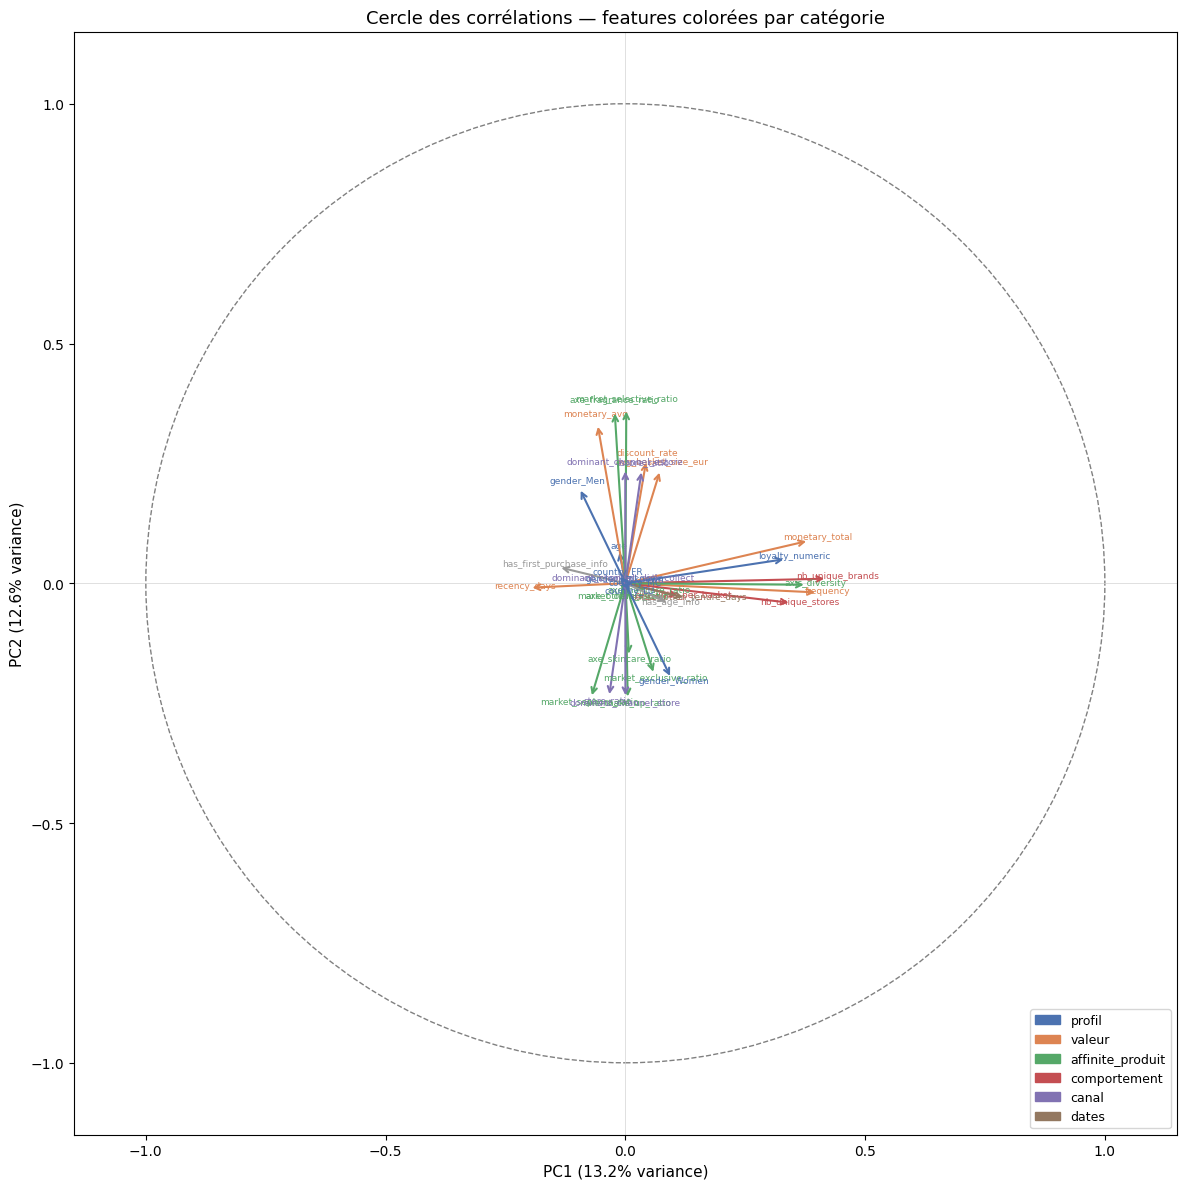

✓ Sauvegardé → figures/correlation_circle.png


In [8]:
fig_corr = plot_correlation_circle(
    X_scaled,
    feature_categories=FEATURE_CATEGORIES,
    category_colors=CATEGORY_COLORS,
    save_path="figures/correlation_circle.png",
)
plt.show()
plt.close(fig_corr)
print("✓ Sauvegardé → figures/correlation_circle.png")

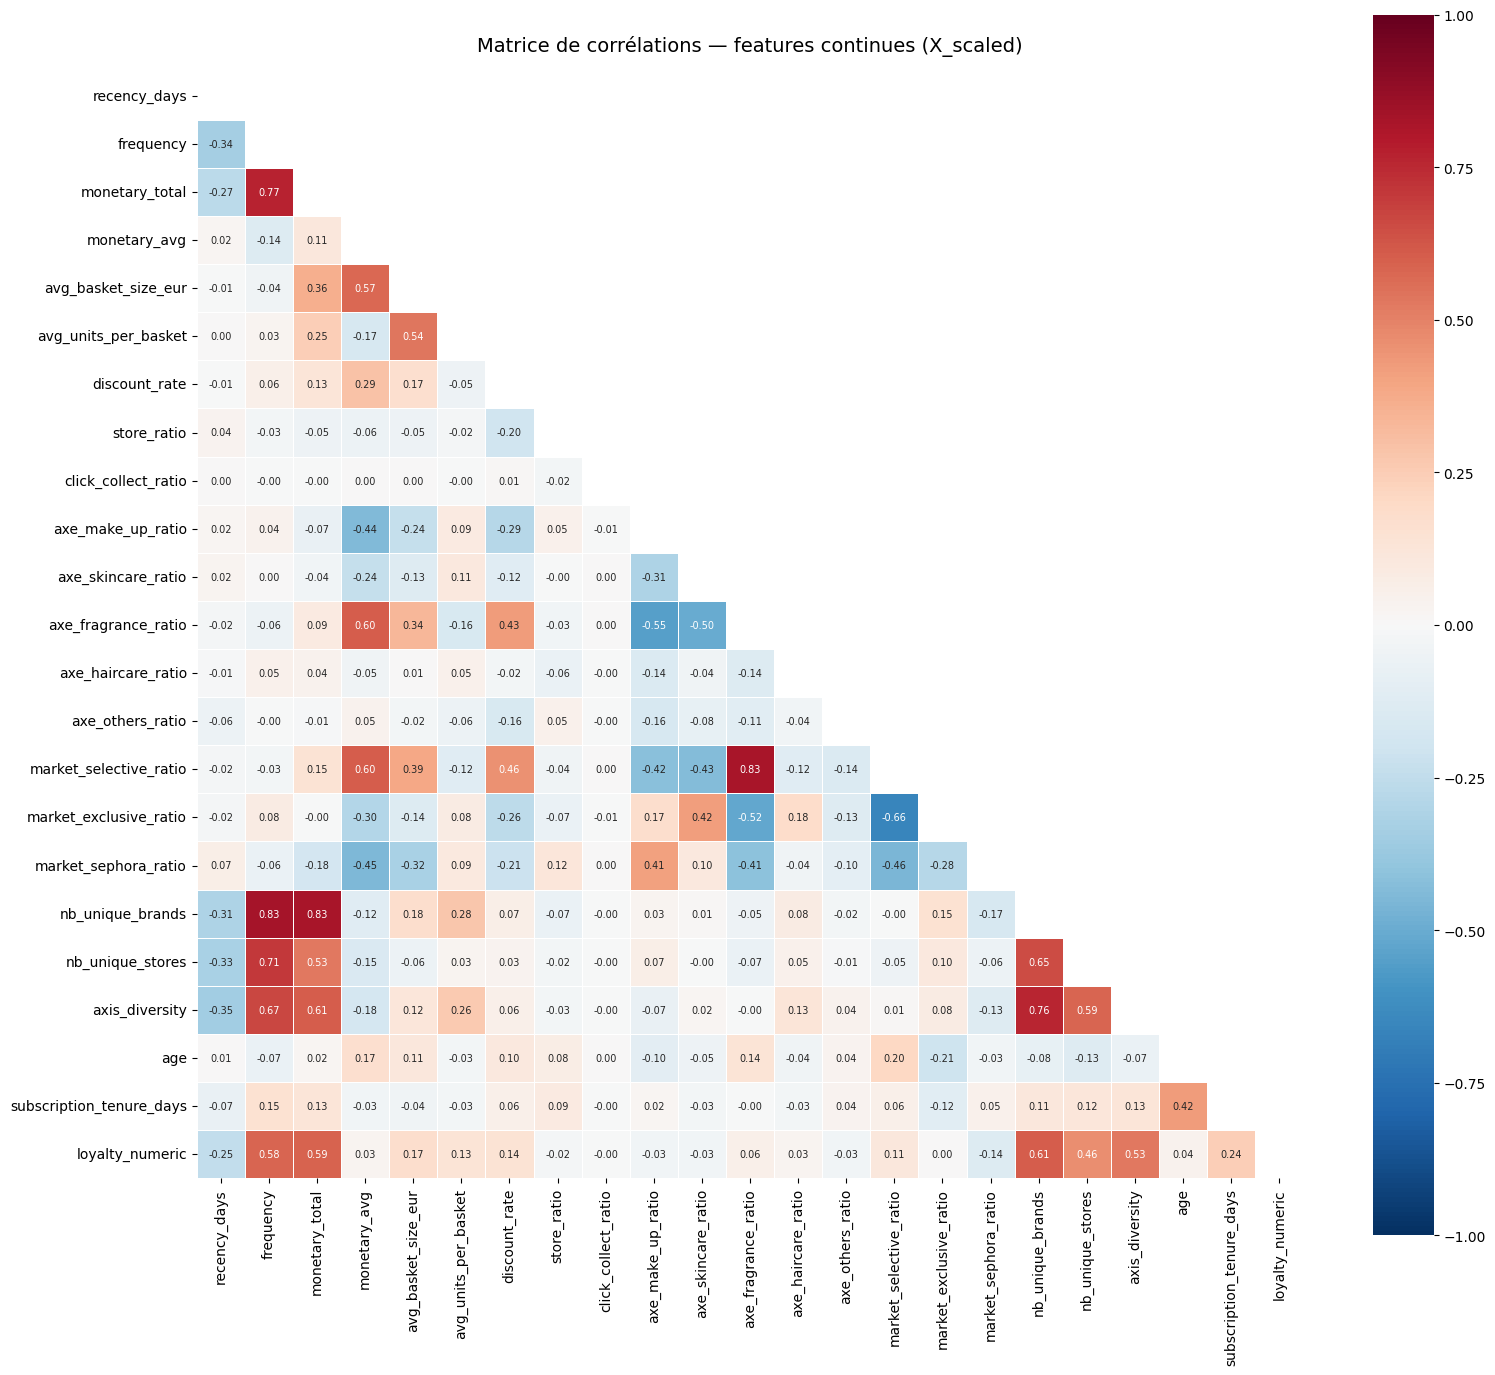

✓ Sauvegardé → figures/correlation_matrix.png

Paires avec |r| > 0.75 :
  frequency  ↔  nb_unique_brands  :  r = 0.829
  monetary_total  ↔  nb_unique_brands  :  r = 0.827
  axe_fragrance_ratio  ↔  market_selective_ratio  :  r = 0.827
  frequency  ↔  monetary_total  :  r = 0.772
  nb_unique_brands  ↔  axis_diversity  :  r = 0.758


In [7]:
# Matrice de corrélations — features continues uniquement
continuous_in_scaled = [c for c in FEATURES_CONTINUOUS if c in X_scaled.columns]
corr_matrix = X_scaled[continuous_in_scaled].corr()

fig_heatmap, ax_hm = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # affiche uniquement le triangle inférieur
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax_hm,
    annot_kws={"size": 7},
)
ax_hm.set_title("Matrice de corrélations — features continues (X_scaled)", fontsize=14, pad=15)
fig_heatmap.tight_layout()
fig_heatmap.savefig("figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_heatmap)
print("✓ Sauvegardé → figures/correlation_matrix.png")

# Lister les paires fortement corrélées (|r| > 0.75)
threshold = 0.75
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

if high_corr:
    print(f"\nPaires avec |r| > {threshold} :")
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1}  ↔  {f2}  :  r = {r:.3f}")
else:
    print(f"\nAucune paire avec |r| > {threshold} détectée ✓")

### Décision (Milan)

> Après inspection du cercle des corrélations, **aucune feature supplémentaire n'a été retirée**.
> Les paires détectées (si elles existent) sont soit sémantiquement distinctes, soit déjà couvertes par les suppressions R1.2.

---
# Section 6 — Clustering : K-Scan (k = 2…30)

On évalue KMeans pour k = 2 à 30 en collectant :
- **Inertia (WCSS)** — méthode du coude : on cherche le point d'inflexion
- **Silhouette** — plus c'est haut, mieux les clusters sont séparés (range -1 à 1)
- **Davies-Bouldin** — plus c'est bas, meilleure est la compacité

Chaque k est tracké dans **MLflow** comme run enfant.

In [9]:
# K-scan avec tracking MLflow
print("Évaluation KMeans k=2..30 avec MLflow tracking…")
metrics_rows = []

with mlflow.start_run(run_name="kmeans-k-scan") as parent_run:
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
        labels = km.fit_predict(X_scaled)
        sil_kwargs = {"random_state": RANDOM_STATE}
        if len(X_scaled) > 10_000:
            sil_kwargs["sample_size"] = 10_000
        sil = silhouette_score(X_scaled, labels, **sil_kwargs)
        db  = davies_bouldin_score(X_scaled, labels)
        ch  = calinski_harabasz_score(X_scaled, labels)

        # Log as steps in parent run → MLflow affiche des courbes complètes
        mlflow.log_metrics(
            {"silhouette": sil, "davies_bouldin": db,
             "calinski_harabasz": ch, "inertia": km.inertia_},
            step=k,
        )

        log_clustering_run(
            run_name=f"kmeans-k{k}",
            params={"k": k, "algorithm": "kmeans"},
            metrics={"silhouette": sil, "davies_bouldin": db,
                     "calinski_harabasz": ch, "inertia": km.inertia_},
            parent_run_id=parent_run.info.run_id,
        )
        metrics_rows.append({"k": k, "inertia": km.inertia_,
                             "silhouette": sil, "davies_bouldin": db,
                             "calinski_harabasz": ch})

metrics_df = pd.DataFrame(metrics_rows)
print(f"✓ {len(metrics_df)} valeurs de k évaluées et loguées dans MLflow.")


Évaluation KMeans k=2..30 avec MLflow tracking…
✓ 29 valeurs de k évaluées et loguées dans MLflow.


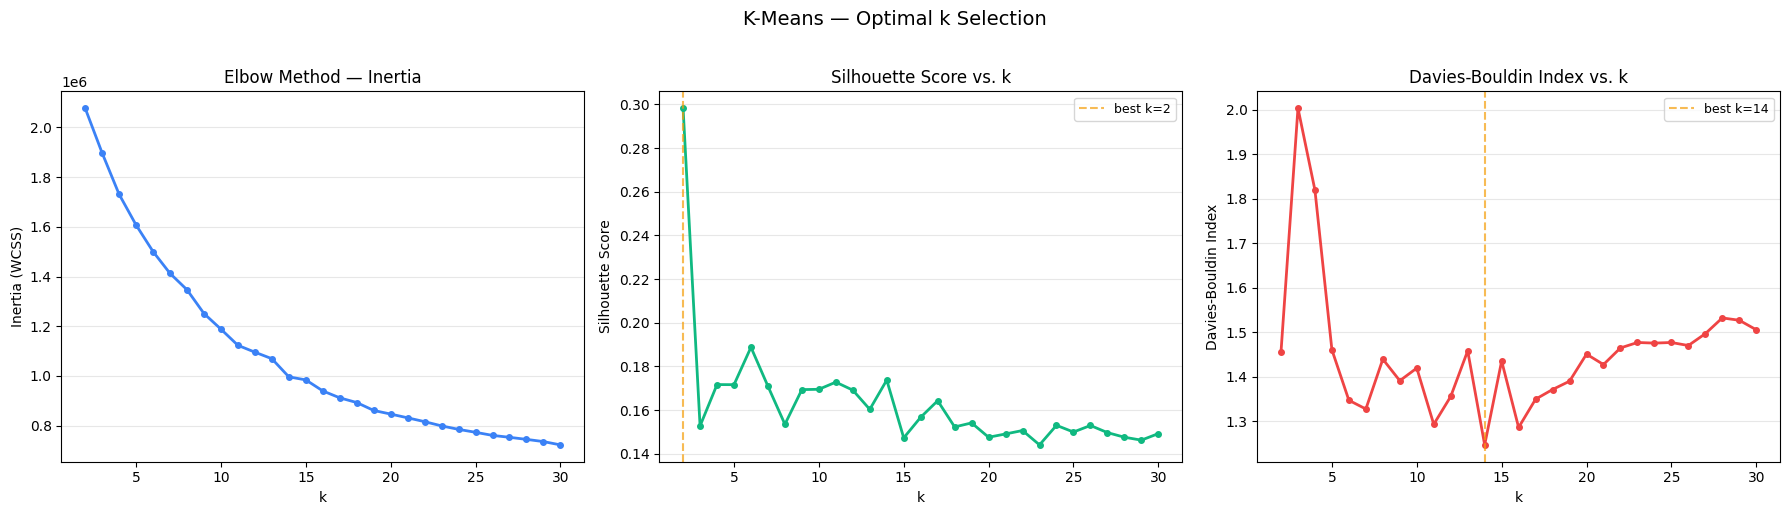

✓ Sauvegardé → figures/elbow_curve.png


In [10]:
# Courbe du coude (inertia, silhouette, Davies-Bouldin)
fig_elbow = plot_elbow_curves(metrics_df, save_path="figures/elbow_curve.png")
plt.show()
plt.close(fig_elbow)
print("✓ Sauvegardé → figures/elbow_curve.png")

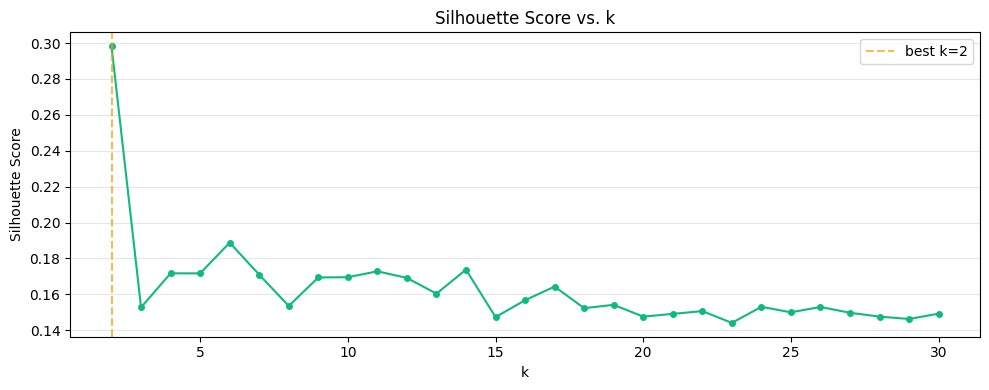

✓ Sauvegardé → figures/silhouette_curve.png


In [11]:
# Courbe silhouette seule (zoom)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(metrics_df["k"], metrics_df["silhouette"], "o-", color="#10B981", markersize=4)
best_k_sil = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
ax.axvline(best_k_sil, color="#F59E0B", linestyle="--", alpha=0.7, label=f"best k={best_k_sil}")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette Score"); ax.set_title("Silhouette Score vs. k")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig("figures/silhouette_curve.png", dpi=150)
plt.show(); plt.close(fig)
print("✓ Sauvegardé → figures/silhouette_curve.png")

### Choix de k (Milan)

> **`k_optimal = X`** — choisi parce que …
>
> *(Remplir après inspection des courbes ci-dessus.)*

In [12]:
# ⬇️  Milan : remplacer X par le k choisi
k_optimal = 10  # placeholder — à ajuster après inspection des courbes
print(f"k_optimal = {k_optimal}")

k_optimal = 10


---
# Section 6b — Diagnostic visuel

Deux visualisations complémentaires pour valider le choix de `k_optimal` :

- **Silhouette plot** — montre la largeur de silhouette de chaque point par cluster. Les clusters homogènes ont des barres larges et alignées. Les barres négatives signalent des points mal attribués.
- **UMAP** — projection 2D non-linéaire de `X_scaled` colorée par label KMeans. Permet de vérifier la séparabilité géométrique des clusters.

/var/folders/84/zqd10b2n6jd17bm5tfw84l680000gn/T/ipykernel_17936/295989841.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k_optimal)


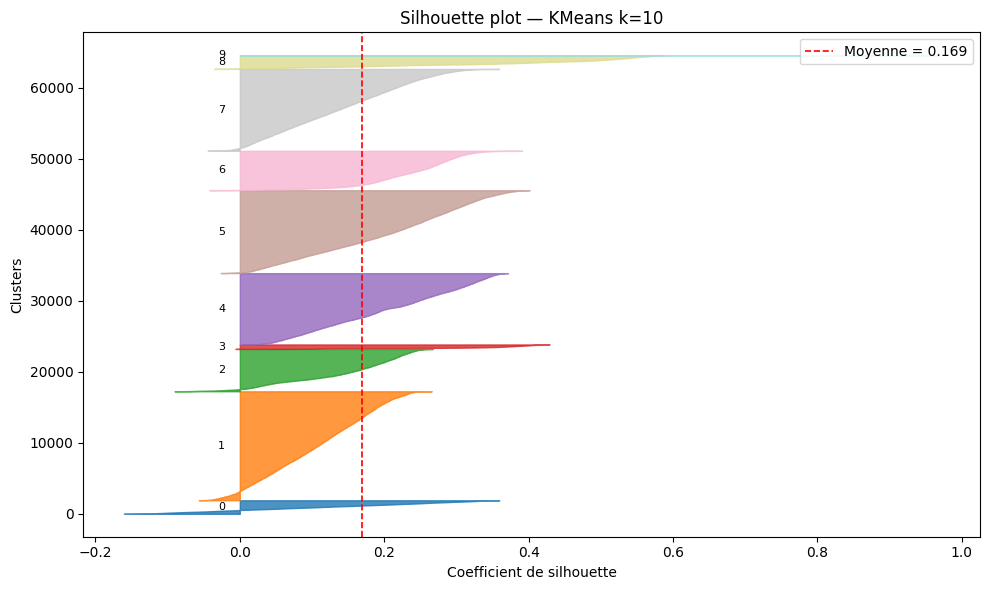

✓ Silhouette moyenne = 0.1689 | Sauvegardé → figures/silhouette_plot.png + loggé dans MLflow


In [13]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# KMeans avec k_optimal pour le diagnostic (identique au modèle final)
_km_diag = KMeans(n_clusters=k_optimal, random_state=RANDOM_STATE, n_init=10, max_iter=300)
_labels_diag = _km_diag.fit_predict(X_scaled)

_sample_sil = silhouette_samples(X_scaled, _labels_diag)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
cmap = cm.get_cmap("tab20", k_optimal)

for i in range(k_optimal):
    ith_sil = np.sort(_sample_sil[_labels_diag == i])
    size_i = ith_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=cmap(i), edgecolor=cmap(i), alpha=0.8)
    ax.text(-0.03, y_lower + 0.5 * size_i, str(i), fontsize=8, va="center")
    y_lower = y_upper + 10

avg_sil = _sample_sil.mean()
ax.axvline(avg_sil, color="red", linestyle="--", linewidth=1.2,
           label=f"Moyenne = {avg_sil:.3f}")
ax.set_xlabel("Coefficient de silhouette")
ax.set_ylabel("Clusters")
ax.set_title(f"Silhouette plot — KMeans k={k_optimal}")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig("figures/silhouette_plot.png", dpi=150)
plt.show()
plt.close(fig)

# Log le silhouette plot dans MLflow
with mlflow.start_run(run_name="silhouette-plot"):
    mlflow.log_param("k", k_optimal)
    mlflow.log_metric("silhouette_mean", avg_sil)
    mlflow.log_artifact("figures/silhouette_plot.png", artifact_path="figures")

print(f"✓ Silhouette moyenne = {avg_sil:.4f} | Sauvegardé → figures/silhouette_plot.png + loggé dans MLflow")

Calcul UMAP (2 composantes) sur X_scaled…


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/84/zqd10b2n6jd17bm5tfw84l680000gn/T/ipykernel_17936/4096893369.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k_optimal)


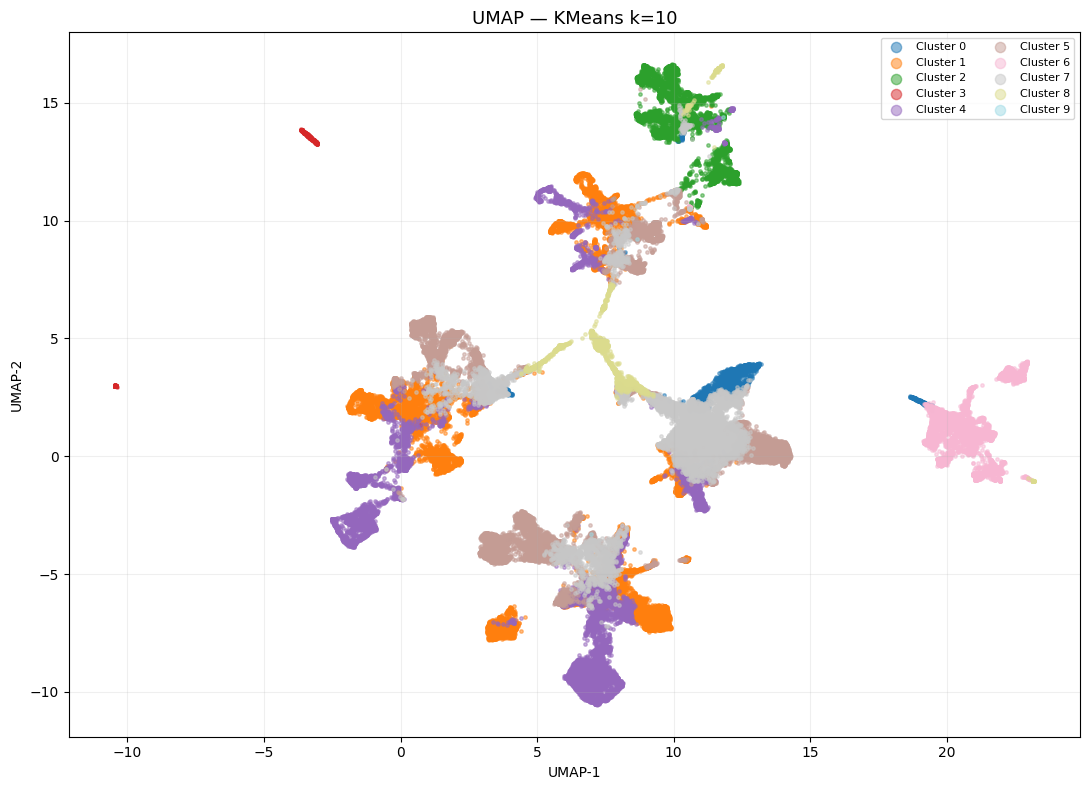

✓ Sauvegardé → figures/umap_clusters.png


In [14]:
import umap

print("Calcul UMAP (2 composantes) sur X_scaled…")
reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
cmap = cm.get_cmap("tab20", k_optimal)
for i in range(k_optimal):
    mask = _labels_diag == i
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               s=6, alpha=0.5, color=cmap(i), label=f"Cluster {i}")

ax.set_title(f"UMAP — KMeans k={k_optimal}", fontsize=13)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=3, loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("figures/umap_clusters.png", dpi=150)
plt.show()
plt.close(fig)
print("✓ Sauvegardé → figures/umap_clusters.png")

---
# Section 7 — Clustering : Modèle Final

On lance KMeans et le clustering hiérarchique (Ward) avec `k_optimal`, puis on compare les métriques pour choisir le modèle final. Les deux runs sont loggés dans MLflow.

In [15]:
# --- KMeans final ---
assert (df_customers.index == X_scaled.index).all(), "Index mismatch"
labels_km, km_model = run_kmeans_final(X_scaled, k=k_optimal, random_state=RANDOM_STATE)
df_customers["kmeans_label"] = labels_km

sil_kwargs = {"random_state": RANDOM_STATE}
if len(X_scaled) > 10_000:
    sil_kwargs["sample_size"] = 10_000

sil_km = silhouette_score(X_scaled, labels_km, **sil_kwargs)
db_km  = davies_bouldin_score(X_scaled, labels_km)
ch_km  = calinski_harabasz_score(X_scaled, labels_km)

log_clustering_run(
    run_name="kmeans-final",
    params={"k": k_optimal, "algorithm": "kmeans",
            "n_features": X_scaled.shape[1], "random_state": RANDOM_STATE},
    metrics={"silhouette": sil_km, "davies_bouldin": db_km, "calinski_harabasz": ch_km},
)
print(f"✅ KMeans final (k={k_optimal}) — sil={sil_km:.4f}, DB={db_km:.4f}, CH={ch_km:.1f}")

✅ KMeans final (k=10) — sil=0.1695, DB=1.4198, CH=6827.9


In [16]:
# Distribution des clusters KMeans
print(f"Distribution des clusters KMeans (k={k_optimal}):")
counts = df_customers["kmeans_label"].value_counts().sort_index()
pcts = df_customers["kmeans_label"].value_counts(normalize=True).sort_index() * 100
for cid in counts.index:
    print(f"  Cluster {cid}: {counts[cid]:>6,} clients ({pcts[cid]:5.2f}%)")

Distribution des clusters KMeans (k=10):
  Cluster 0:  1,902 clients ( 2.95%)
  Cluster 1: 15,334 clients (23.79%)
  Cluster 2:  5,947 clients ( 9.22%)
  Cluster 3:    626 clients ( 0.97%)
  Cluster 4: 10,032 clients (15.56%)
  Cluster 5: 11,664 clients (18.09%)
  Cluster 6:  5,538 clients ( 8.59%)
  Cluster 7: 11,519 clients (17.87%)
  Cluster 8:  1,904 clients ( 2.95%)
  Cluster 9:      3 clients ( 0.00%)


In [17]:
# --- Clustering hiérarchique (Ward) ---
# ⬇️  Milan : définir le nombre de lignes à utiliser (None = dataset complet, mais très lent)
hc_n_samples = 10_000  # ex: 5000, 10_000, None

labels_hc = run_hierarchical(X_scaled, k=k_optimal, n_samples=hc_n_samples)
df_customers["hclust_label"] = labels_hc

sil_hc = silhouette_score(X_scaled, labels_hc, **sil_kwargs)
db_hc  = davies_bouldin_score(X_scaled, labels_hc)
ch_hc  = calinski_harabasz_score(X_scaled, labels_hc)

log_clustering_run(
    run_name="hierarchical-final",
    params={"k": k_optimal, "algorithm": "agglomerative_ward",
            "n_features": X_scaled.shape[1], "hc_n_samples": hc_n_samples or len(X_scaled)},
    metrics={"silhouette": sil_hc, "davies_bouldin": db_hc, "calinski_harabasz": ch_hc},
)
n_msg = f"(sur {hc_n_samples:,} lignes, propagé sur {len(X_scaled):,})" if hc_n_samples else f"(sur {len(X_scaled):,} lignes)"
print(f"✅ Hierarchical Ward (k={k_optimal}) {n_msg} — sil={sil_hc:.4f}, DB={db_hc:.4f}, CH={ch_hc:.1f}")


✅ Hierarchical Ward (k=10) (sur 10,000 lignes, propagé sur 64,469) — sil=0.1720, DB=1.2764, CH=6237.6


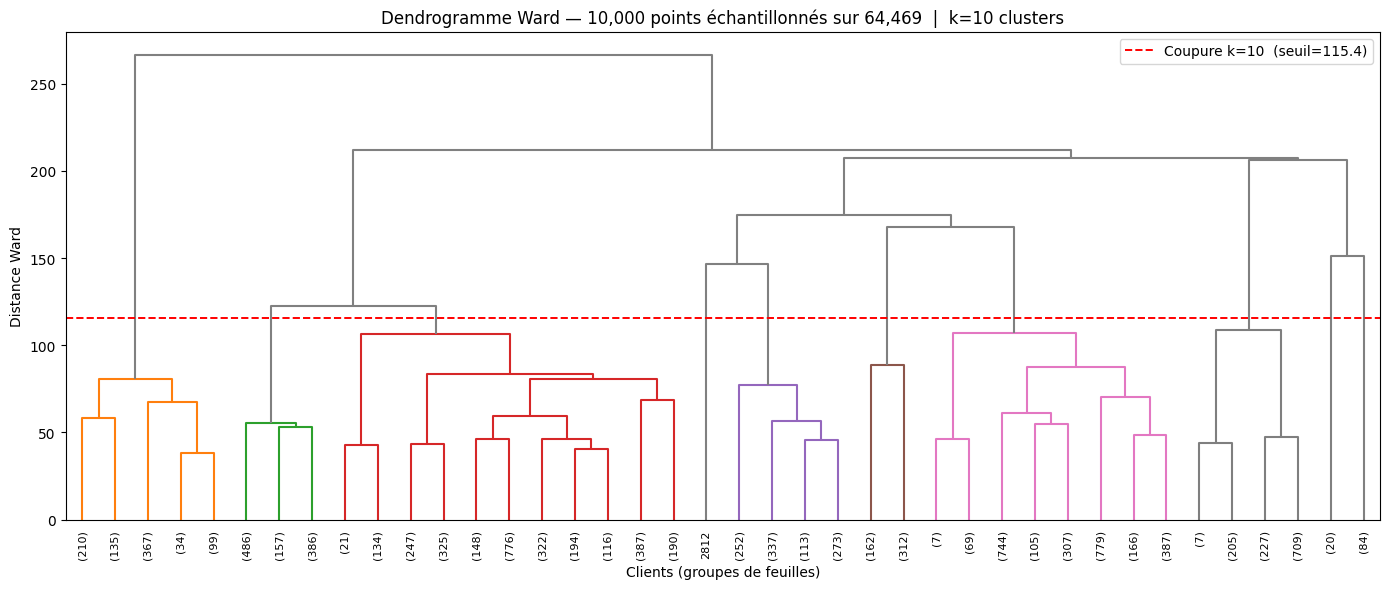

✓ Dendrogramme (sur 10,000 points) — sauvegardé → figures/dendrogram.png + loggé dans MLflow


In [18]:
from src.clustering import plot_dendrogram

_dendro_n = min(hc_n_samples or len(X_scaled), 10_000)  # ≤ 2 000 points pour la vitesse
fig_dendro = plot_dendrogram(
    X_scaled,
    k=k_optimal,
    n_samples=_dendro_n,
    save_path="figures/dendrogram.png",
)
plt.show()
plt.close(fig_dendro)

# Log dans MLflow comme artifact lié au run hiérarchique
with mlflow.start_run(run_name="hierarchical-dendrogram"):
    mlflow.log_param("k", k_optimal)
    mlflow.log_param("dendro_n_samples", _dendro_n)
    mlflow.log_artifact("figures/dendrogram.png", artifact_path="figures")

print(f"✓ Dendrogramme (sur {_dendro_n:,} points) — sauvegardé → figures/dendrogram.png + loggé dans MLflow")


In [19]:
# Tableau comparatif KMeans vs Hierarchical (sera mis à jour après GMM)
comparison_results = [
    {"Algorithme": "KMeans", "Silhouette": sil_km, "Davies-Bouldin": db_km, "Calinski-Harabasz": ch_km},
    {"Algorithme": "Hierarchical (Ward)", "Silhouette": sil_hc, "Davies-Bouldin": db_hc, "Calinski-Harabasz": ch_hc},
]
comparison = pd.DataFrame(comparison_results)
print(comparison.to_string(index=False))

         Algorithme  Silhouette  Davies-Bouldin  Calinski-Harabasz
             KMeans    0.169515        1.419826        6827.858864
Hierarchical (Ward)    0.172023        1.276355        6237.589800


---
## US-4.4 — Gaussian Mixture Models (GMM)

Le GMM est un modèle de clustering *soft* (probabiliste) : chaque client a une probabilité d'appartenir à chaque cluster.
On utilise `covariance_type='diag'` car avec 43 features, `'full'` est numériquement instable et trop lent.

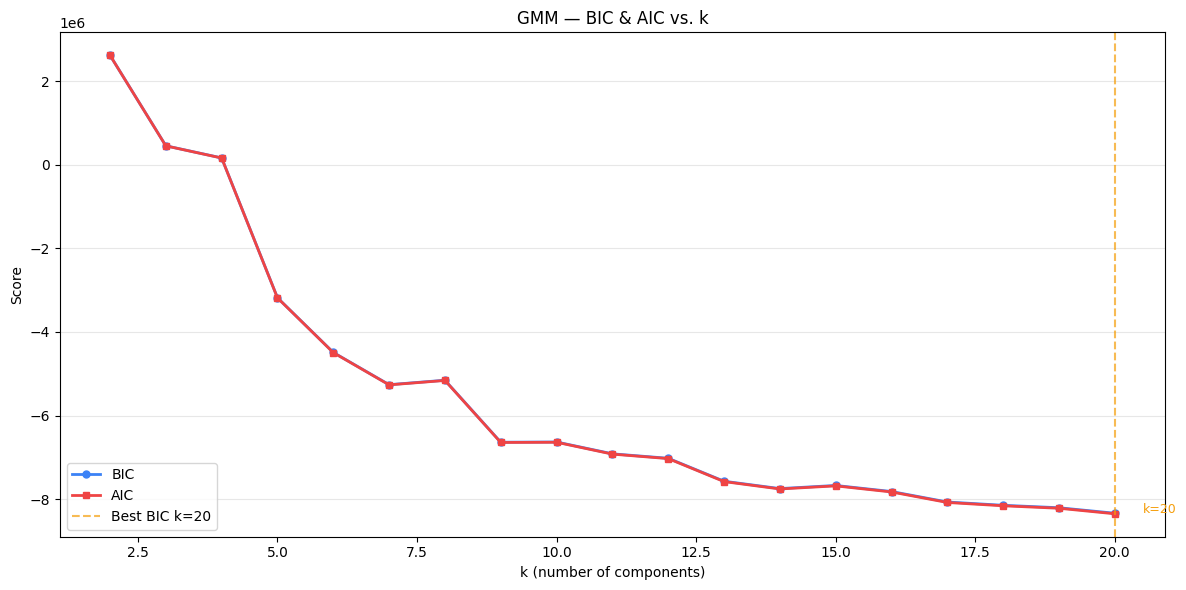

✅ BIC/AIC évalués pour k=2..20 — best BIC à k=20
   Sauvegardé → figures/gmm_bic_aic.png


In [20]:
# --- Reload modules just in case ---
import sys, importlib
import src.clustering, src.visualization
importlib.reload(src.clustering)
importlib.reload(src.visualization)

# --- Task 2: BIC / AIC curves ---
from src.clustering import evaluate_gmm_bic_aic
from src.visualization import plot_gmm_bic_aic

bic_aic_df = evaluate_gmm_bic_aic(X_scaled, k_range=range(2, 21))
fig_bic = plot_gmm_bic_aic(bic_aic_df, save_path="figures/gmm_bic_aic.png")
plt.show()
plt.close(fig_bic)

best_bic_k = int(bic_aic_df.loc[bic_aic_df["bic"].idxmin(), "k"])
print(f"✅ BIC/AIC évalués pour k=2..20 — best BIC à k={best_bic_k}")
print(f"   Sauvegardé → figures/gmm_bic_aic.png")

In [21]:
# --- Task 1 & 3: Run GMM final + compute metrics ---
from src.clustering import run_gmm

labels_gmm, gmm_model = run_gmm(X_scaled, k=k_optimal)
df_customers["gmm_label"] = labels_gmm

sil_gmm = silhouette_score(X_scaled, labels_gmm, **sil_kwargs)
db_gmm  = davies_bouldin_score(X_scaled, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_scaled, labels_gmm)

print(f"✅ GMM (k={k_optimal}, covariance='diag') — sil={sil_gmm:.4f}, DB={db_gmm:.4f}, CH={ch_gmm:.1f}")
print(f"   Converged: {gmm_model.converged_}, n_iter: {gmm_model.n_iter_}")

✅ GMM (k=10, covariance='diag') — sil=0.1124, DB=2.1556, CH=4734.6
   Converged: True, n_iter: 25


In [22]:
# --- Task 4: Log GMM run to MLflow ---
# Calcul du min_cluster_pct
gmm_counts = pd.Series(labels_gmm).value_counts(normalize=True)
min_cluster_pct = gmm_counts.min() * 100

log_clustering_run(
    run_name="gmm-final",
    params={
        "k": k_optimal,
        "algorithm": "gmm_diag",
        "n_features": X_scaled.shape[1],
        "random_state": RANDOM_STATE,
    },
    metrics={
        "silhouette": sil_gmm,
        "davies_bouldin": db_gmm,
        "calinski_harabasz": ch_gmm,
        "min_cluster_pct": min_cluster_pct,
    },
)
print(f"✅ MLflow run 'gmm-final' loggé — min_cluster_pct={min_cluster_pct:.2f}%")

✅ MLflow run 'gmm-final' loggé — min_cluster_pct=0.00%


In [23]:
# --- US-4.5 Task 1: Build comparison table with min_cluster_pct ---
import sys, importlib
import src.clustering
importlib.reload(src.clustering)
from src.clustering import build_comparison_table, select_best_algorithm

# Rebuild comparison_results in standardised format
comparison_results = [
    {"algorithm": "KMeans", "k": k_optimal, "silhouette": sil_km, "davies_bouldin": db_km, "calinski_harabasz": ch_km},
    {"algorithm": "Hierarchical (Ward)", "k": k_optimal, "silhouette": sil_hc, "davies_bouldin": db_hc, "calinski_harabasz": ch_hc},
    {"algorithm": "GMM (diag)", "k": k_optimal, "silhouette": sil_gmm, "davies_bouldin": db_gmm, "calinski_harabasz": ch_gmm},
]

comp_df = build_comparison_table(comparison_results, df_customers)
print("📊 Algorithm Comparison Table (US-4.5 — AC 1):")
print(comp_df.to_string(index=False))
print()

# --- US-4.5 Task 2: Select best algorithm ---
best_row = select_best_algorithm(comp_df)
best_algo = best_row["algorithm"]
print(f"🏆 Best algorithm: {best_algo} (score={best_row['score']:.4f})")

📊 Algorithm Comparison Table (US-4.5 — AC 1):
          algorithm  k  silhouette  davies_bouldin  calinski_harabasz  min_cluster_pct
             KMeans 10    0.169515        1.419826        6827.858864         0.004653
Hierarchical (Ward) 10    0.172023        1.276355        6237.589800         0.009307
         GMM (diag) 10    0.112373        2.155592        4734.573030         0.004653

🏆 Best algorithm: Hierarchical (Ward) (score=-0.9201)


In [24]:
# --- US-4.5 Task 4: Log comparison table to MLflow ---
comp_csv_path = "data/processed/comparison_results.csv"
comp_df.to_csv(comp_csv_path, index=False)

with mlflow.start_run(run_name="algorithm-comparison"):
    mlflow.log_artifact(comp_csv_path, artifact_path="comparison")
    mlflow.log_param("best_algorithm", best_algo)
    mlflow.log_metric("best_silhouette", float(best_row["silhouette"]))

print(f"✅ MLflow run 'algorithm-comparison' — comparison_results.csv loggé comme artifact")
print(f"   Fichier local: {comp_csv_path}")

✅ MLflow run 'algorithm-comparison' — comparison_results.csv loggé comme artifact
   Fichier local: data/processed/comparison_results.csv


---
## US-4.5 — Algorithm Comparison & Final Selection

Le tableau ci-dessus compare KMeans, Hierarchical (Ward) et GMM sur les métriques Silhouette, Davies-Bouldin, Calinski-Harabasz et la taille minimale de cluster.  
Le meilleur algorithme est sélectionné automatiquement via un score combiné.

### Justification du choix (Milan)

> **Modèle retenu :** *(Remplir après inspection du tableau ci-dessus, ex: KMeans)*
>
> **Raisons :** *(3-5 phrases justifiant le choix : meilleure silhouette, clusters équilibrés, reproductibilité, etc.)*

---
# Section 8 — Profiling des segments

On compare la moyenne de chaque feature par cluster à la moyenne globale. Les valeurs sont exprimées en **z-scores** (écarts par rapport à la moyenne globale en unités d'écart-type). Une valeur de +1.5 signifie que le cluster est 1.5 écarts-types au-dessus de la moyenne.

In [25]:
# --- US-4.5 Task 2 (cont.): Assign final_cluster + cluster_id ---
# Map best algorithm name to its label column in df_customers
ALGO_TO_LABEL_COL = {
    "KMeans": "kmeans_label",
    "Hierarchical (Ward)": "hclust_label",
    "GMM (diag)": "gmm_label",
}
label_col = ALGO_TO_LABEL_COL[best_algo]
df_customers["final_cluster"] = df_customers[label_col]
df_customers["cluster_id"] = df_customers["final_cluster"]

print(f"✅ final_cluster = df_customers['{label_col}']  (best_algo={best_algo})")
print(f"   cluster_id alias added")
print(f"   Distribution: {df_customers['final_cluster'].value_counts().sort_index().to_dict()}")

# Calculer les profils par cluster (features continues uniquement)
continuous_in_scaled = [c for c in FEATURES_CONTINUOUS if c in X_scaled.columns]

# Nettoyer les valeurs inf dans df_customers avant le calcul des z-scores
df_clean = df_customers[continuous_in_scaled].replace([np.inf, -np.inf], np.nan)

profile_df = df_clean.groupby(df_customers["final_cluster"]).mean()
global_mean = df_clean.mean()
global_std = df_clean.std()

zscore_df = (profile_df - global_mean) / global_std
print(f"Profile shape: {zscore_df.shape} (clusters × features)")

✅ final_cluster = df_customers['hclust_label']  (best_algo=Hierarchical (Ward))
   cluster_id alias added
   Distribution: {0: 8023, 1: 14813, 2: 2500, 3: 5572, 4: 18275, 5: 514, 6: 5986, 7: 112, 8: 6, 9: 8668}
Profile shape: (10, 25) (clusters × features)


In [34]:
# ⬇️  Milan : lister les clusters à masquer du heatmap (liste vide = tous affichés)
CLUSTERS_TO_HIDE = []

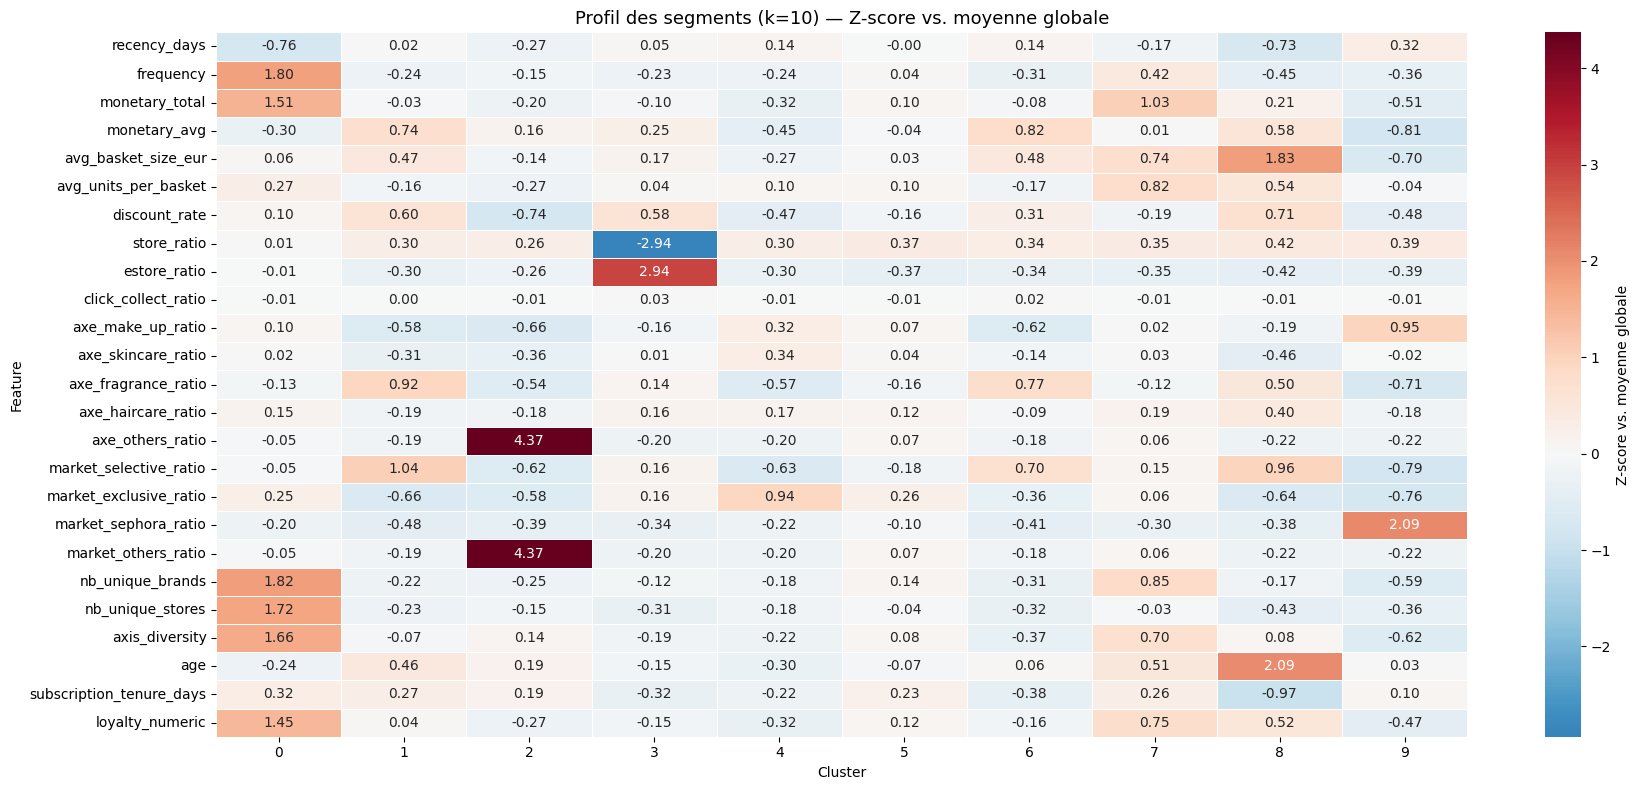

✓ Sauvegardé → figures/cluster_profiles.png


In [35]:
# Heatmap des profils
zscore_plot = zscore_df.drop(index=[c for c in CLUSTERS_TO_HIDE if c in zscore_df.index])

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(zscore_plot.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"label": "Z-score vs. moyenne globale"})
hidden_msg = f" — clusters masqués : {CLUSTERS_TO_HIDE}" if CLUSTERS_TO_HIDE else ""
ax.set_title(f"Profil des segments (k={k_optimal}){hidden_msg} — Z-score vs. moyenne globale", fontsize=13)
ax.set_xlabel("Cluster"); ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig("figures/cluster_profiles.png", dpi=150)
plt.show(); plt.close(fig)
print("✓ Sauvegardé → figures/cluster_profiles.png")

### Observations clés par cluster (Milan), vont changer si le modèle ou les hyperparamètres changent

> **Cluster 0 :** CLIENTS FIDÈLES : haute fréquence d'achat, beaucoup de dépense, dans différents stores, haute fidélité, mais volume par achat moyen : ils viennent souvent mais n'achètent pas tant que ça
>
> **Cluster 1 :** Ne viennent pas si souvent mais achètent beaucoup, sont vieux.
>
> **Cluster 2 :** N'achètent peu, un peu vieux
>
> **Cluster 3 :** Achètent en ligne, peu en stores
>
> **Cluster 4 :** N'achètent peu, un peu jeune
>
> **Cluster 5 :** Très moyen
>
> **Cluster 6 :** 
>
> **Cluster 7 :** 
>
> **Cluster 8 :** 
>
> **Cluster 9 :** 
> *(À remplir après inspection de la heatmap.)*

---
# Section 9 — Export

On exporte le DataFrame `df_customers` enrichi des labels de cluster vers un fichier CSV
pour analyse ultérieure ou intégration dans un dashboard.

In [28]:
# --- US-4.5 Task 3: Export customers_with_clusters.csv ---
assert "final_cluster" in df_customers.columns, "final_cluster missing!"
assert "cluster_id" in df_customers.columns, "cluster_id missing!"

df_customers.to_csv("data/processed/customers_with_clusters.csv", index=False)
last_cols = list(df_customers.columns[-4:])
print(f"✅ Exported: {len(df_customers):,} rows → data/processed/customers_with_clusters.csv")
print(f"   Dernières colonnes: {last_cols}")

✅ Exported: 64,469 rows → data/processed/customers_with_clusters.csv
   Dernières colonnes: ['hclust_label', 'gmm_label', 'final_cluster', 'cluster_id']


In [29]:
print("Pour parcourir les expériences MLflow :")
print("  mlflow ui")
print("  → http://127.0.0.1:5000")

Pour parcourir les expériences MLflow :
  mlflow ui
  → http://127.0.0.1:5000


---
# Section 10 — US-4.6 : Cluster Stability Validation (Bootstrap)

On teste la stabilité du clustering final en ré-exécutant l'algorithme retenu sur **5 sous-échantillons bootstrap (80%)** du jeu de données. L'**Adjusted Rand Index (ARI)** mesure la concordance entre les labels du sous-échantillon et les labels du jeu complet.

- **Seuil : Mean ARI ≥ 0.70** → clustering stable
- Si Mean ARI < 0.70 → instabilité détectée, réviser k ou l'algorithme

In [30]:
# --- US-4.6 Task 1: Bootstrap stability ---
from src.validation import bootstrap_stability
from src.clustering import run_kmeans_final

# Wrap the chosen algorithm as a callable
def final_algo(X_sub):
    labels, _ = run_kmeans_final(X_sub, k_optimal)
    return labels

stability_df = bootstrap_stability(X_scaled, df_customers["final_cluster"], final_algo)
print(stability_df.to_string(index=False))
print(f"\nMean ARI: {stability_df['ari'].mean():.3f}")
print(f"Min  ARI: {stability_df['ari'].min():.3f}")
print(f"Max  ARI: {stability_df['ari'].max():.3f}")

 bootstrap  n_samples    ari  n_clusters
         1      51575 0.7153          10
         2      51575 0.8674          10
         3      51575 0.6316          10
         4      51575 0.5523          10
         5      51575 0.7092          10

Mean ARI: 0.695
Min  ARI: 0.552
Max  ARI: 0.867


In [31]:
# --- US-4.6 Task 2: Evaluate stability threshold ---
mean_ari = stability_df["ari"].mean()
if mean_ari >= 0.70:
    print(f"✓ Stable clustering (Mean ARI = {mean_ari:.3f} ≥ 0.70)")
else:
    print(f"⚠ Unstable clustering (Mean ARI = {mean_ari:.3f} < 0.70)")
    print("Consider: reduce k, try different algorithm, or review feature selection")

⚠ Unstable clustering (Mean ARI = 0.695 < 0.70)
Consider: reduce k, try different algorithm, or review feature selection


In [32]:
# --- US-4.6 Task 4: Log stability results to MLflow ---
import mlflow

mean_ari = stability_df["ari"].mean()
min_ari = stability_df["ari"].min()
max_ari = stability_df["ari"].max()

with mlflow.start_run(run_name="stability-validation"):
    mlflow.log_params({
        "n_bootstraps": 5,
        "subsample_frac": 0.80,
        "algorithm": best_algo,
        "k": k_optimal,
    })
    mlflow.log_metrics({
        "mean_ari": mean_ari,
        "min_ari": min_ari,
        "max_ari": max_ari,
    })
    stability_csv = "data/processed/stability_results.csv"
    stability_df.to_csv(stability_csv, index=False)
    mlflow.log_artifact(stability_csv, artifact_path="validation")

print(f"✅ MLflow run 'stability-validation' loggé")
print(f"   Params: n_bootstraps=5, subsample_frac=0.80, algorithm={best_algo}, k={k_optimal}")
print(f"   Metrics: mean_ari={mean_ari:.4f}, min_ari={min_ari:.4f}, max_ari={max_ari:.4f}")
print(f"   Artifact: {stability_csv}")

✅ MLflow run 'stability-validation' loggé
   Params: n_bootstraps=5, subsample_frac=0.80, algorithm=Hierarchical (Ward), k=10
   Metrics: mean_ari=0.6952, min_ari=0.5523, max_ari=0.8674
   Artifact: data/processed/stability_results.csv


---
## E4 — Synthèse finale

| Élément | Valeur |
|---|---|
| **Algorithme retenu** | Sélectionné automatiquement (US-4.5) |
| **k optimal** | Déterminé par silhouette (US-4.1) |
| **Stabilité (Mean ARI)** | Calculé ci-dessus (seuil ≥ 0.70) |
| **Colonne finale** | `df_customers['final_cluster']` |

**Gate statement:** Clustering complete — proceeding to E5 Segment Profiling.

In [33]:
cd "/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora" && mlflow ui

[Errno 2] No such file or directory: '/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora && mlflow ui'
/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora
